# Sandbox: The Hidden Manifold Model & Phase Transitions

In this exercise, we are going to build a simple cross-modal alignment simulation. 

## Section 0: Training a Generalized Linear Model (GLM) via Gradient Descent

Before we look at hidden manifolds or complex constraints, let's look at how a standard **Generalized Linear Model (GLM)** learns. 

In machine learning, a GLM maps a high-dimensional input vector $x \in \mathbb{R}^D$ to a continuous label $y \in \mathbb{R}$ using a weight vector $w \in \mathbb{R}^D$ and an activation function $f$:

$$y = f(w^\top x) + \xi$$

where $\xi$ is random Gaussian noise. If $f(a) = a$, this is standard linear regression.

### The Learning Goal:
We will generate synthetic data where we know the true hidden weights $w_{\text{true}}$. We will give our student model the inputs $X$ and labels $Y$, and see if it can recover $w_{\text{true}}$ using **Gradient Descent**.

### The Optimization:
We want to minimize the Mean Squared Error (MSE) loss:
$$\mathcal{L}(w) = \frac{1}{2N} \sum_{\mu=1}^P (\langle x^\mu, w\rangle - y^\mu)^2 = \frac{1}{2N} \|Xw - Y\|_2^2$$

Gradient Descent updates the weights by taking a small step in the direction *opposite* to the gradient:
$$w \leftarrow w - \eta \nabla_w \mathcal{L}$$
where $\eta$ is the learning rate.

*Excercice*: _Given $\mathcal{L}(w)$ defined above, find analytically what's the value of $w$ that minimize this loss._ Is always possible to define a solution? If not, can I approximate a solution?

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Fix seed for reproducibility
torch.manual_seed(2026)

# 1. Define dimensions
N = 100  # Number of training samples
D = 5    # Number of features (ambient dimension)

# 2. Generate random inputs X
X = torch.randn(N, D)

# 3. Define the "true" world weights that the student must discover
w_true = torch.tensor([2.0, -1.5, 0.5, 0.0, 1.2])

# 4. Generate the labels Y with a tiny bit of observation noise
noise = torch.randn(N) * 0.1
Y = X @ w_true + noise

print("Data generated safely!")
print(r"X shape (Samples x Features):", X.shape)
print("Y shape (Labels):", Y.shape)

### Section 0.1: Synthetic Data Generation (Code Cell)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Fix seed for reproducibility
torch.manual_seed(2026)

# 1. Define dimensions
P = 200  # Number of training samples
D = 100    # Input dimension (number of features)

# 2. Generate random inputs X
X = torch.randn(P,D) 
# 3. Define the "true" world weights that the student must discover
w_true = torch.randn(D)

# 4. Generate the labels Y with a tiny bit of observation noise
noise = torch.randn(D,1) * 0.1
Y = X @ w_true + noise

# At the moment, we don't consider any scaling because the model is linear. 
# However, if we were to use a nonlinearity like erf, we would need to scale X by 1/sqrt(D) or the weights. 



print("Data generated safely!")
print(r"X shape (Samples x Features):", X.shape)
print("Y shape (Labels):", Y.shape)

Data generated safely!
X shape (Samples x Features): torch.Size([200, 100])
Y shape (Labels): torch.Size([100, 200])


### Section 0.2: Training the GLM with Raw PyTorch (Code Cell)

In [ ]:
# Initialize the student's weights randomly
# We set requires_grad=True so PyTorch tracks derivatives for this variable
w_student = torch.randn(D, requires_grad=True)

# Optimization parameters
learning_rate = 0.1
training_steps = 40

# Track history to plot the learning trajectory later
loss_history = []
overlap_history = []  # Cosine similarity between w_student and w_true

print("Starting Gradient Descent loop...\n")

for step in range(training_steps):
    # 1. Forward Pass: Compute the model's predictions
    # This is just matrix-vector multiplication: \hat{Y} = X w
    Y_pred = X @ w_student
    
    # 2. Compute the Mean Squared Error Loss
    loss = 0.5 * torch.mean((Y_pred - Y) ** 2)
    ## Here I use the Means Squared Error, but I could also use the Sum Squared Error.
    # The choice between mean and sum will affect the scale of the gradients and thus the learning rate you might want to use.
    
    # 3. Backward Pass: Let PyTorch calculate the gradients automatically
    # This computes \nabla_w \mathcal{L} via backpropagation
    loss.backward()
    
    # 4. Gradient Descent Update Step
    # We use torch.no_grad() so PyTorch doesn't try to track the update step itself
    with torch.no_grad():
        # w = w - eta * grad
        w_student -= learning_rate * w_student.grad
        
        # CRITICAL STEP: Manually clear the gradients for the next iteration
        # CRITICAL STEP: Manually clear the gradients in-place for the next iteration
        w_student.grad.zero_()
        
    # Track metrics
    loss_history.append(loss.item())
    
    # Compute the student-teacher overlap (Order Parameter 'm' equivalent)
    with torch.no_grad():
        similarity = torch.dot(w_student, w_true) / (torch.norm(w_student) * torch.norm(w_true))
        overlap_history.append(similarity.item())
        
    if step % 5 == 0 or step == training_steps - 1:
        print(f"Step {step:2d} | Loss: {loss.item():.4f} | Alignment with true weights: {similarity.item():.4f}")

print("\nTraining Complete!")
print("First 5 true Weights:   ", w_true.numpy()[:5])
print("First 5 learned Weights:", w_student.detach().numpy()[:5])

Starting Gradient Descent loop...

Step  0 | Loss: 152.8268 | Alignment with true weights: 0.0193
Step  5 | Loss: 35.8809 | Alignment with true weights: 0.5511
Step 10 | Loss: 12.8342 | Alignment with true weights: 0.7760
Step 15 | Loss: 5.9908 | Alignment with true weights: 0.8662
Step 20 | Loss: 3.3123 | Alignment with true weights: 0.9103
Step 25 | Loss: 2.0520 | Alignment with true weights: 0.9357
Step 30 | Loss: 1.3744 | Alignment with true weights: 0.9518
Step 35 | Loss: 0.9719 | Alignment with true weights: 0.9628
Step 39 | Loss: 0.7578 | Alignment with true weights: 0.9693

Training Complete!
First 5 true Weights:    [ 0.46938902  2.0906813  -1.3288472  -0.771869    1.1833389 ]
First 5 learned Weights: [ 0.3230075   2.1655848  -1.0853037  -0.86101335  0.8124362 ]


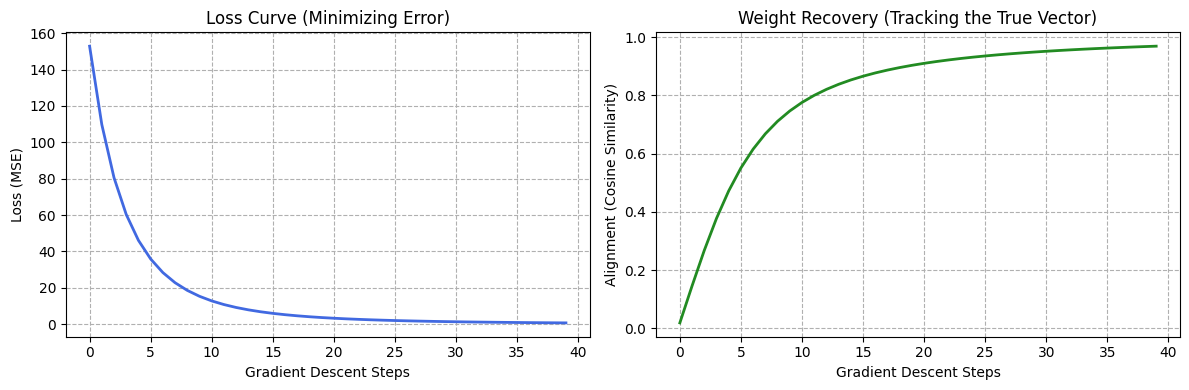

In [65]:
# Plotting the results for Moritz to analyze
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Loss Optimization
ax1.plot(loss_history, color='royalblue', lw=2)
ax1.set_xlabel('Gradient Descent Steps')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Loss Curve (Minimizing Error)')
ax1.grid(True, linestyle='--')

# Plot 2: Alignment / Order Parameter Tracking
ax2.plot(overlap_history, color='forestgreen', lw=2)
ax2.set_xlabel('Gradient Descent Steps')
ax2.set_ylabel('Alignment (Cosine Similarity)')
ax2.set_title('Weight Recovery (Tracking the True Vector)')
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

**Before doing any comparison with static theory: It's  important to check that  the hyperparemeters as the number of GD steps (epochs),  learning rate (lr) are well tunned so the loss MSE loss converge.**

# Section 1: The Non-Linear GLM (The $\text{erf}$ Perceptron)

Now, let's make the world non-linear. We will use the error function as our activation:
$$f(x) = \text{erf}(x) = \frac{2}{\sqrt{\pi}} \int_0^x e^{-t^2} dt$$

This function maps any real number smoothly between $-1$ and $1$, acting just like a standard neural network activation function (like tanh).

In the statistical mechanics of machine learning, we study system behavior in the **thermodynamic limit**: where both the number of training patterns $P$ and the input dimension $D$ go to infinity, but their ratio remains fixed:

$$\alpha = \frac{P}{D}$$

This $\alpha$ acts as our **sample-to-parameter ratio**. In some papers the wrongly call $\alpha$ _sample complexity_. 

### The Experiment:
We will fix the input dimension $D$. Then, we will sweep across a range of $\alpha$ values. For each $\alpha$, the notebook will automatically calculate the required number of training points:
$$P = \lfloor \alpha \times D \rfloor$$

We will plot both the **Test Loss** and the **Teacher-Student Alignment ($m$)** as a function of $\alpha$ to see exactly how much data the non-linear model needs before it transitions from memorizing noise to learning the true structure.

### Section 1.1: The Core Experiment Loop (Code Cell)

In [77]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Fix seed for consistency
torch.manual_seed(42)

# Global Problem Dimensions
D = 100     # Input dimension (number of features)
steps = 2000 # Gradient descent updates
lr = 0.01   # Learning rate

# Generate a fixed, true teacher vector of unit length
w_true = torch.randn(D)

def run_glm_experiment(alpha, l2_lambda=0.01, use_random_labels=False):
    """
    Calculates P from alpha, generates data, trains an erf-student via GD with L2 regularization,
    and returns final Test Loss and Alignment (m).
    """
    # Calculate number of training points P based on alpha
    P = int(alpha * D)
    
    # --- DATA GENERATION ---
    # Note: Added /np.sqrt(D) to X_train so it matches your X_test scaling. 
    # This prevents the erf function from saturating during training!
    X_train = torch.randn(P, D) / np.sqrt(D) 
    Y_train = torch.erf(X_train @ w_true) + torch.randn(P) * 0.01
    
    if use_random_labels:
        # Shuffling labels breaks the structural link with X
        Y_train = Y_train[torch.randperm(P)]
        
    # Unseen Test Set (Always structured to measure true generalization)
    P_test = 200
    X_test = torch.randn(P_test, D) / np.sqrt(D)
    Y_test = torch.erf(X_test @ w_true)
    
    # --- TRAINING THE STUDENT ---
    w_student = torch.randn(D, requires_grad=True)
    
    for step in range(steps):
        # Forward pass using the non-linear erf activation
        Y_pred = torch.erf(X_train @ w_student)
        
        # 1. Base  Squared Error Loss
        mse_loss = 0.5 * torch.sum((Y_pred - Y_train) ** 2)
        # In this case, I used the squared error, to make it to the same order(magnitude) as the L2 penalty 
        
        # 2. L2 Regularization Penalty: 0.5 * \lambda * ||w||_2^2
        l2_penalty = 0.5 * l2_lambda * torch.sum(w_student ** 2)
        
        
        # Total Loss (Hamiltonian of the system)
        total_loss = mse_loss + l2_penalty
        

        
        # Compute total gradients automatically
        total_loss.backward()
        
        with torch.no_grad():
            w_student -= lr * w_student.grad
            w_student.grad.zero_() 
            
    # --- EVALUATION ---
    with torch.no_grad():
        # Evaluate on unseen Test Set
        Y_test_pred = torch.erf(X_test @ w_student)
        test_loss = 0.5 * torch.mean((Y_test_pred - Y_test) ** 2).item()
        
        # Calculate Alignment/Overlap 'm'
        m = (torch.dot(w_student, w_true) / (torch.norm(w_student) * torch.norm(w_true))).item()
        
    return test_loss, abs(m)

print("Alpha-scaled experiment engine with L2 regularization built!")

Alpha-scaled experiment engine with L2 regularization built!


### Section 1.3: Sweeping α and Plotting the Curves (Code Cell)

In [75]:
# Sweep over alpha = P/D 
alpha_values = np.linspace(0.2, 5.0, 15)  # From underparameterized to heavily overparameterized

structured_losses, structured_alignments = [], []
random_losses, random_alignments = [], []

print("Running sweep over alpha values...")
for alpha in alpha_values:
    # Train on Structured data
    loss_s, m_s = run_glm_experiment(alpha, use_random_labels=False)
    structured_losses.append(loss_s)
    structured_alignments.append(m_s)
    
    # Train on Random data
    loss_r, m_r = run_glm_experiment(alpha, use_random_labels=True)
    random_losses.append(loss_r)
    random_alignments.append(m_r)
    
    P_actual = int(alpha * D)
    print(f"alpha = {alpha:.1f} (P={P_actual:3d}) | Struct Align: {m_s:.3f} | Noise Align: {m_r:.3f}")



Running sweep over alpha values...
alpha = 0.2 (P= 20) | Struct Align: 0.295 | Noise Align: 0.274
alpha = 0.5 (P= 54) | Struct Align: 0.348 | Noise Align: 0.124
alpha = 0.9 (P= 88) | Struct Align: 0.772 | Noise Align: 0.060
alpha = 1.2 (P=122) | Struct Align: 0.865 | Noise Align: 0.030
alpha = 1.6 (P=157) | Struct Align: 0.967 | Noise Align: 0.006
alpha = 1.9 (P=191) | Struct Align: 0.995 | Noise Align: 0.072
alpha = 2.3 (P=225) | Struct Align: 0.996 | Noise Align: 0.036
alpha = 2.6 (P=260) | Struct Align: 1.000 | Noise Align: 0.101
alpha = 2.9 (P=294) | Struct Align: 1.000 | Noise Align: 0.071
alpha = 3.3 (P=328) | Struct Align: 1.000 | Noise Align: 0.029
alpha = 3.6 (P=362) | Struct Align: 1.000 | Noise Align: 0.052
alpha = 4.0 (P=397) | Struct Align: 1.000 | Noise Align: 0.041
alpha = 4.3 (P=431) | Struct Align: 1.000 | Noise Align: 0.053
alpha = 4.7 (P=465) | Struct Align: 1.000 | Noise Align: 0.016
alpha = 5.0 (P=500) | Struct Align: 1.000 | Noise Align: 0.058


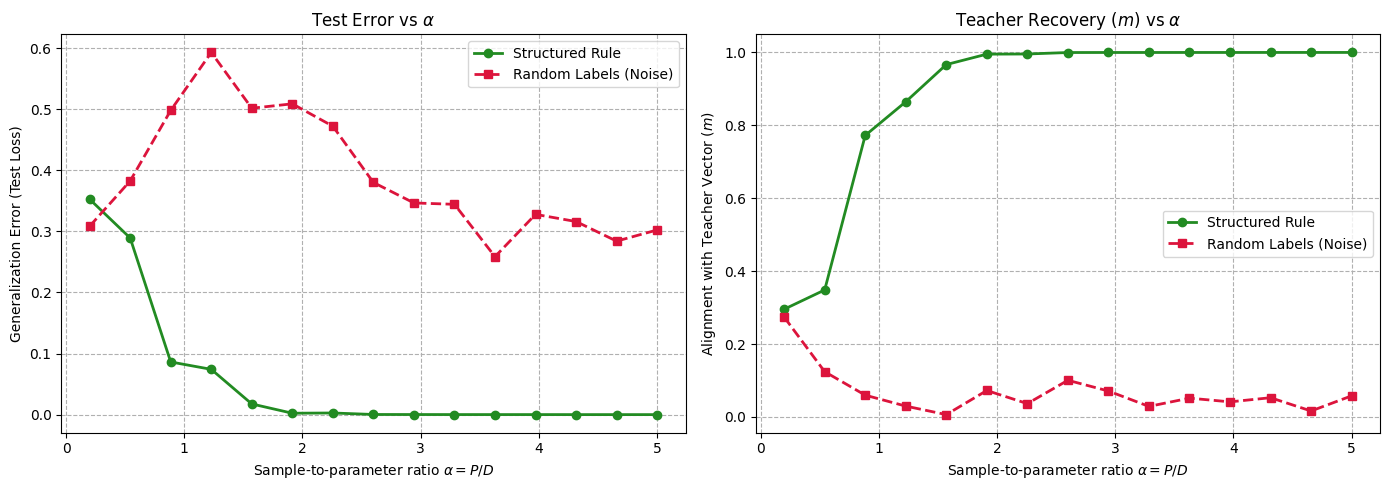

In [78]:
# --- VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test Loss vs Alpha
ax1.plot(alpha_values, structured_losses, 'o-', color='forestgreen', lw=2, label='Structured Rule')
ax1.plot(alpha_values, random_losses, 's--', color='crimson', lw=2, label='Random Labels (Noise)')
ax1.set_xlabel(r'Sample-to-parameter ratio $\alpha = P/D$')
ax1.set_ylabel('Generalization Error (Test Loss)')
ax1.set_title(r'Test Error vs $\alpha$')
ax1.grid(True, linestyle='--')
ax1.legend()

# Plot 2: Alignment m vs Alpha
ax2.plot(alpha_values, structured_alignments, 'o-', color='forestgreen', lw=2, label='Structured Rule')
ax2.plot(alpha_values, random_alignments, 's--', color='crimson', lw=2, label='Random Labels (Noise)')
ax2.set_xlabel(r'Sample-to-parameter ratio $\alpha = P/D$')
ax2.set_ylabel('Alignment with Teacher Vector ($m$)')
ax2.set_title(r'Teacher Recovery ($m$) vs $\alpha$')
ax2.grid(True, linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()